In [92]:
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
import seaborn as sns
print(confusion_matrix)

<function confusion_matrix at 0x000002837B7D0D60>


In [54]:
#train a model using pipeline
#load the irirs datasets
data = load_iris()
X,y = data.data,data.target
labels= data.feature_names

In [55]:
#Instiate a pipeline consisting of StandardScaler,PCA,KNeighborsClassifiers
pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('pca',PCA(n_components= 2,)),
    ('knn',KNeighborsClassifier(n_neighbors = 5,))
])

In [56]:
#split the data into training date set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.20,random_state = 42,stratify = y)

In [57]:
#fit the pipeline on the trainig set
pipeline.fit(X_train,y_train)

#measure the pipeline accuracy on the test data 
test_score = pipeline.score(X_test,y_test)
print(f"{test_score:.3f}")

0.900


In [58]:
#get the model prediction
y_pred = pipeline.predict(X_test)

In [59]:
#generate the confusion_matrix and plot it
confusion_matrix = confusion_matrix(y_test,y_pred)

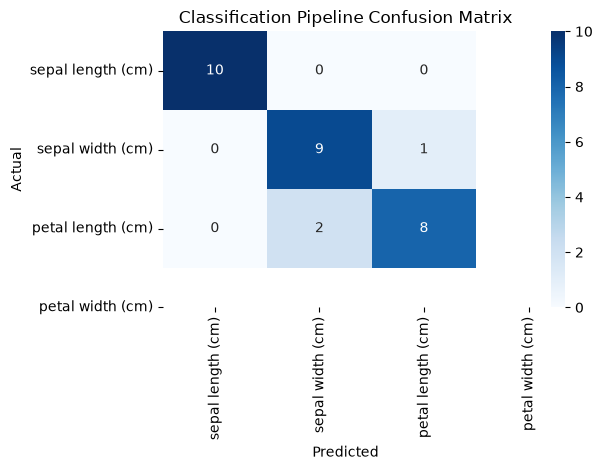

In [60]:
#create a single plot for confusion matrix
plt.figure()
sns.heatmap(confusion_matrix, annot=True, cmap='Blues', fmt='d',
            xticklabels=labels, yticklabels=labels)
plt.title('Classification Pipeline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [73]:
#tune hyperparameter using pipeline within cross validation gridsearch
pipeline = Pipeline(
    [
        ('scaler',StandardScaler()),
        ('pca',PCA()),
        ('knn',KNeighborsClassifier())
    ]
)

In [78]:
#hyperparameter serach grid to for number of PCA COMPONENTS AND Kneighbors
param_grid = {
    'knn__n_neighbors': [3, 5, 7],
    'pca__n_components': [2, 3]
}

In [79]:
#choose a cross validation
#to ensure target is startified we ude standardscaler cross validation
cv = StratifiedKFold(n_splits = 5,shuffle = True,random_state = 42)

In [80]:
best_model = GridSearchCV(
    estimator = pipeline,
    param_grid =param_grid ,
    cv = cv,
    scoring = 'accuracy',
    verbose =2
)

In [81]:
best_model.fit(X_train,y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_c

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [3, 5, ...], 'pca__n_components': [2, 3]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_

In [82]:
test_score = best_model.score(X_test,y_test)
print(f"{test_score:.3f}")

0.933


In [84]:
best_model.best_params_

{'knn__n_neighbors': 3, 'pca__n_components': 3}

In [90]:
print(confusion_matrix)

[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]
